# Setup

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
from pprint import pprint

In [10]:
def normalize_str(s:str) -> str:
  return " ".join(word.capitalize() for word in s.split("_"))

In [11]:
def get_number_of_instances(df:pd.DataFrame, col:str) -> pd.DataFrame:
  df = (df.groupby(col)
          .agg(number_of_instances = (col, 'count'))
          .sort_values('number_of_instances', ascending=False)
          .reset_index())

  df['percent'] = df['number_of_instances'] / df['number_of_instances'].sum() * 100

  return df

In [12]:
def get_summary_stats(df:pd.DataFrame, col:str) -> pd.DataFrame:
  df_temp = df[col].agg(['mean', lambda x: x.mode()[0], 'median', 'var', 'std'])
  df_temp = pd.concat([df_temp, df[col].quantile([.25, .75])], ignore_index = True)
  df_temp.index = ['mean', 'mode', 'median','var', 'std', 'q1', 'q3']
  return df_temp.reset_index().pivot_table(columns = "index", values = col).reset_index(names = "column_name")

In [13]:
def barplot(df:pd.DataFrame, x:str, y:str = "number_of_instances", n = 10, figsize:tuple[int, int] = (11, 5)) -> None:
  df_plot = df.head(n).copy() if df.shape[0] > n else df.copy()

  df_plot[x] = df_plot[x].apply(
      lambda x: textwrap.fill(str(x).title(), width=35)
  )

  plt.subplots(figsize=figsize)

  sns.barplot(
      data=df_plot,
      x=x,
      y=y
  )

  sns.despine()
  plt.title(f"{normalize_str(x)} Counts", loc = "left")

  plt.tight_layout()
  plt.show()

In [14]:
def horizontal_barplot(
    df:pd.DataFrame,
    y:str,
    x:str = "number_of_instances",
    n:int = 10,
    figsize:tuple[int, int] = (11, 5)
    ) -> None:
  df_plot = df.head(n).copy() if df.shape[0] > n else df.copy()

  df_plot[y] = df_plot[y].apply(
      lambda x: textwrap.fill(str(x).title(), width=35)
  )

  plt.figure(figsize=figsize)

  sns.barplot(
      data=df_plot,
      y=y,
      x=x
  )

  sns.despine()
  plt.title(f"{normalize_str(col)} Count", loc="left")
  plt.xlabel("Number of Instances")
  plt.ylabel("")
  plt.tight_layout()
  plt.show()

In [15]:
def get_num_nulls(df:pd.DataFrame, col:str) -> int:
  return df[col].isna().sum()

In [288]:
#assumes the dataframe is sorted
def find_num_groups( df: pd.DataFrame, threshold: float = 90, percent_col: str = "percent") -> tuple[int, float]:

    if not 0 < threshold <= 100:
        raise ValueError("Threshold must be between 0 and 100.")

    if threshold == 100:
      return df.shape[0], 100

    cumulative_percent = df[percent_col].cumsum()

    n_groups = (cumulative_percent <= threshold).sum()
    actual_percent = cumulative_percent.iloc[n_groups]

    return n_groups.item() + 1, actual_percent.item()

# Import and Inspection

In [16]:
df = pd.read_parquet('master.parquet')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2196737 entries, 0 to 2196736
Data columns (total 24 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   health_service_area             object 
 1   hospital_county                 object 
 2   facility_name                   object 
 3   age_group                       object 
 4   gender                          object 
 5   race                            object 
 6   ethnicity                       object 
 7   length_of_stay                  Int64  
 8   type_of_admission               object 
 9   patient_disposition             object 
 10  discharge_year                  Int64  
 11  ccsr_diagnosis_description      object 
 12  apr_drg_description             object 
 13  apr_mdc_description             object 
 14  apr_severity_of_illness_code    Int64  
 15  apr_severity_of_illness         object 
 16  apr_risk_of_mortality           object 
 17  apr_medical_surgical       

In [18]:
df.isna().sum()

,0
health_service_area,5295
hospital_county,5295
facility_name,0
age_group,0
gender,0
race,0
ethnicity,0
length_of_stay,0
type_of_admission,0
patient_disposition,0


# Characterisitcs (Univariate)

### Health Service Area

In [19]:
col = 'health_service_area'
df_temp = get_number_of_instances(df, col)
df_temp

,health_service_area,number_of_instances,percent
0,New York City,996124,45.455184
1,Long Island,359214,16.391673
2,Hudson Valley,243870,11.128289
3,Capital/Adirondacks,143613,6.553356
4,Western NY,142041,6.481623
5,Finger Lakes,140528,6.412581
6,Central NY,138048,6.299414
7,Southern Tier,28004,1.277880


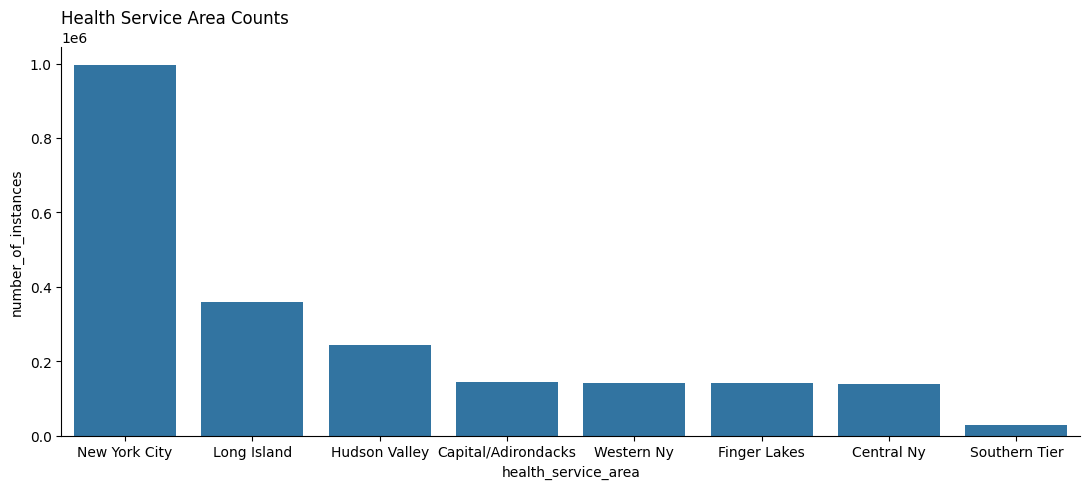

In [20]:
barplot(df_temp, col, 'number_of_instances', figsize=(11, 5))

### Hospital County

In [21]:
col = 'hospital_county'
df_temp = get_number_of_instances(df, col).head(10)
df_temp

,hospital_county,number_of_instances,percent
0,New York,389375,17.767981
1,Kings,200536,9.150870
2,Nassau,192048,8.763545
3,Queens,185610,8.469766
4,Suffolk,167166,7.628128
5,Bronx,165312,7.543526
6,Westchester,127036,5.796914
7,Erie,112360,5.127218
8,Monroe,105204,4.800675
9,Onondaga,71592,3.266890


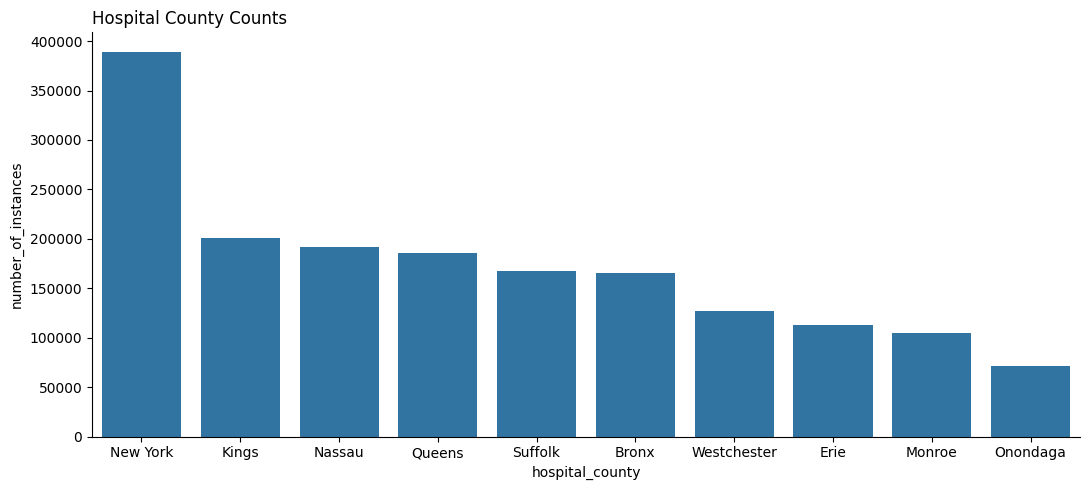

In [22]:
barplot(df_temp, col, 'number_of_instances')

### Facility Name

In [23]:
col = 'facility_name'
df_temp = get_number_of_instances(df, col).head(20)
df_temp

,facility_name,number_of_instances,percent
0,MOUNT SINAI HOSPITAL,53353,2.428739
1,NYU LANGONE HOSPITALS,50456,2.296861
2,NORTH SHORE UNIVERSITY HOSPITAL,49153,2.237546
3,NEW YORK-PRESBYTERIAN HOSPITAL - COLUMBIA PRES...,45983,2.093241
4,STRONG MEMORIAL HOSPITAL,40244,1.831990
5,LONG ISLAND JEWISH MEDICAL CENTER,39948,1.818515
6,NYU LANGONE HOSPITAL-LONG ISLAND,38698,1.761613
7,MONTEFIORE MEDICAL CENTER - HENRY & LUCY MOSES...,37784,1.720006
8,ALBANY MEDICAL CENTER HOSPITAL,36882,1.678945
9,STONY BROOK UNIVERSITY HOSPITAL,36013,1.639386


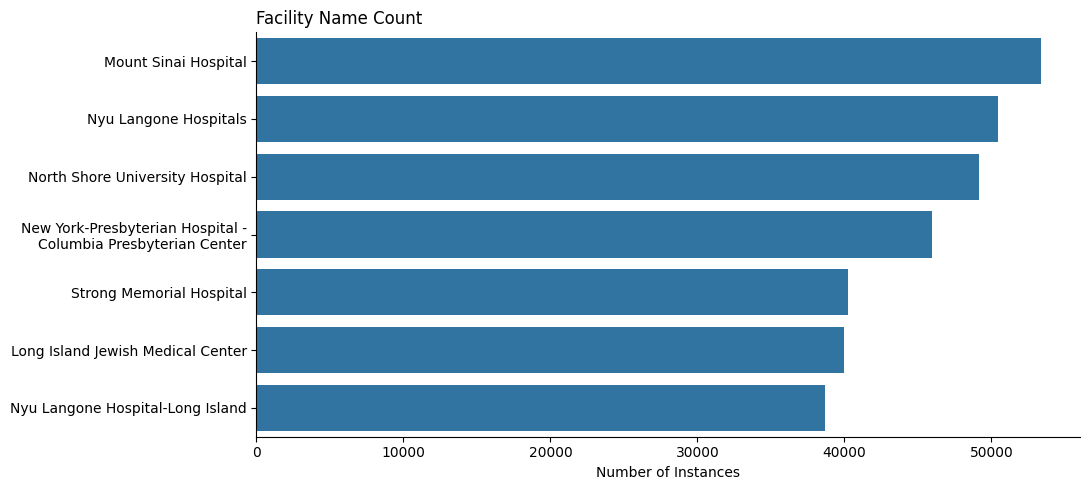

In [24]:
horizontal_barplot(df_temp.head(7), col, figsize=(11, 5))

### Age Group

In [26]:
col = 'age_group'
df_temp = get_number_of_instances(df, col)
df_temp

,age_group,number_of_instances,percent
0,70 or Older,706970,32.182733
1,50-69,581333,26.463477
2,30-49,423270,19.268124
3,0-17,301927,13.744340
4,18-29,183237,8.341326


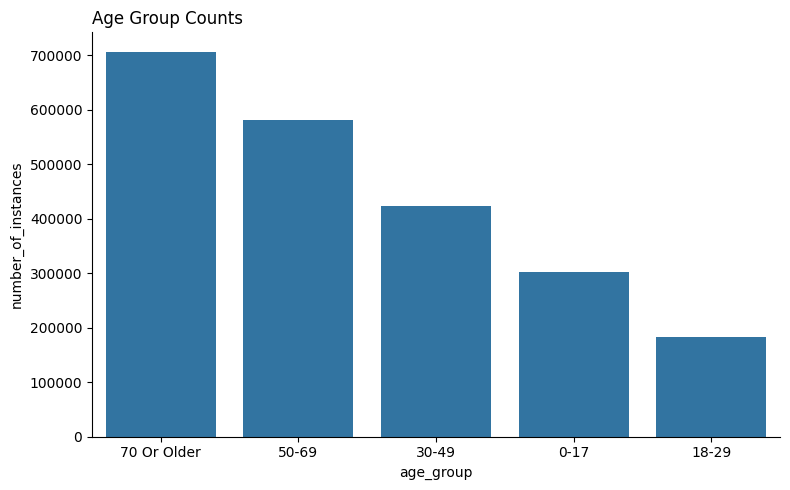

In [27]:
barplot(df_temp, col, figsize = (8, 5))

### Gender

In [28]:
col = "gender"
df_temp = get_number_of_instances(df, col)
df_temp

,gender,number_of_instances,percent
0,F,1195617,54.426952
1,M,1000735,45.555522
2,U,385,0.017526


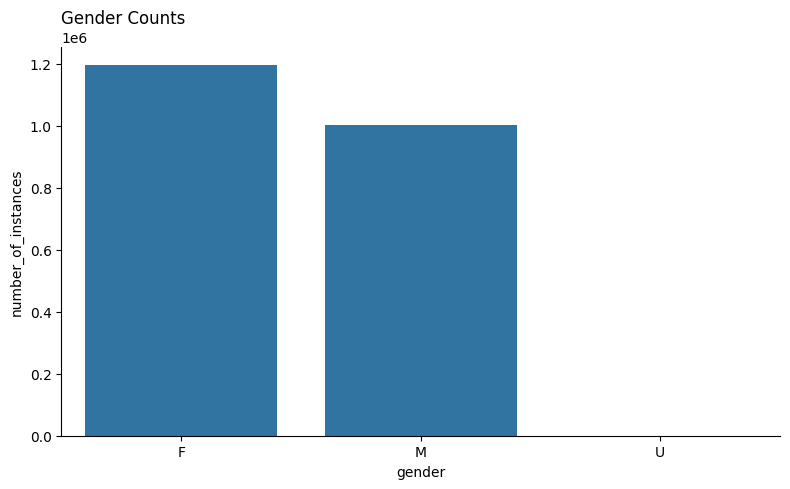

In [29]:
barplot(df_temp, col, figsize = (8, 5))

### Race

In [30]:
col = "race"
df_temp = get_number_of_instances(df, col)
df_temp

,race,number_of_instances,percent
0,White,1147354,52.229921
1,Other Race,620872,28.263374
2,Black/African American,395419,18.000289
3,Multi-racial,33092,1.506416


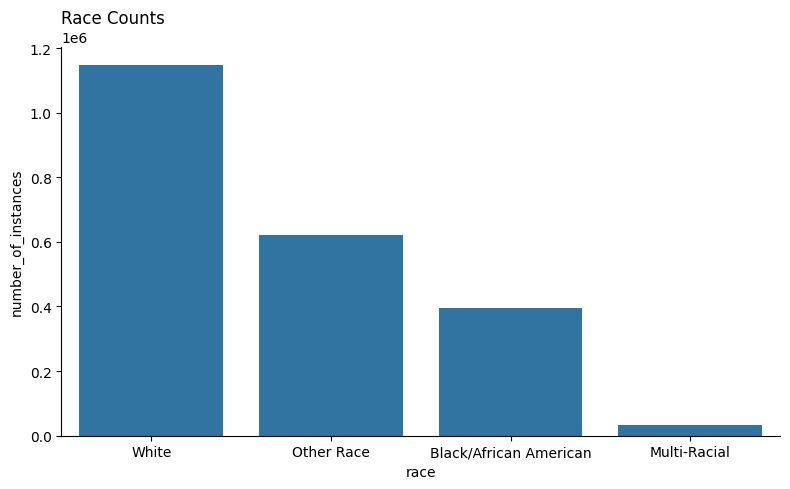

In [31]:
barplot(df_temp, "race", figsize = (8, 5))

### Ethnicity

In [32]:
col = "ethnicity"
df_temp = get_number_of_instances(df, col)
df_temp

,ethnicity,number_of_instances,percent
0,Not Span/Hispanic,1540538,70.128468
1,Spanish/Hispanic,363988,16.569485
2,Unknown,289643,13.185147
3,Multi-ethnic,2568,0.116901


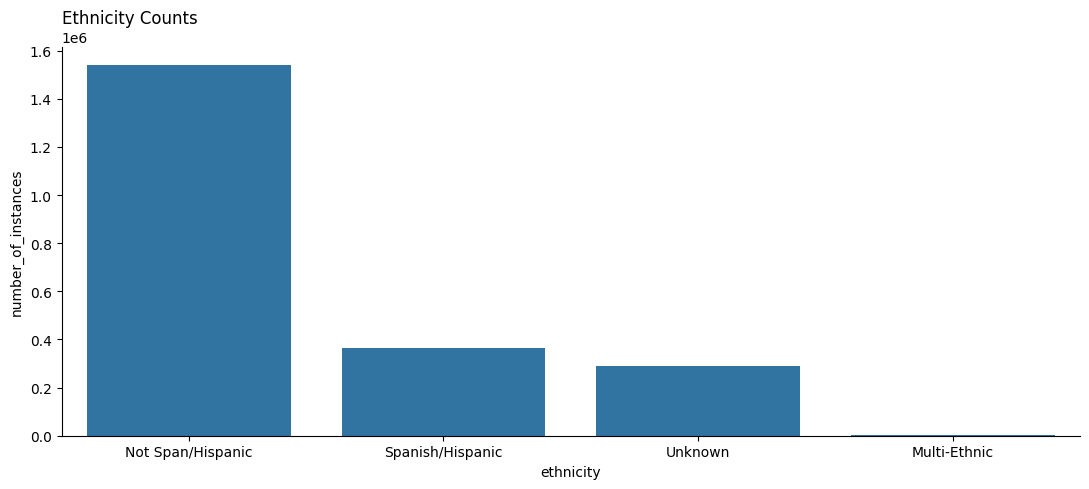

In [33]:
barplot(df_temp, col)

### Length of Stay

In [34]:
col = "length_of_stay"
df_temp = get_summary_stats(df, col)
df_temp

index,column_name,mean,median,mode,q1,q3,std,var
0,length_of_stay,5.810259,3.0,2.0,2.0,6.0,8.826429,77.905848


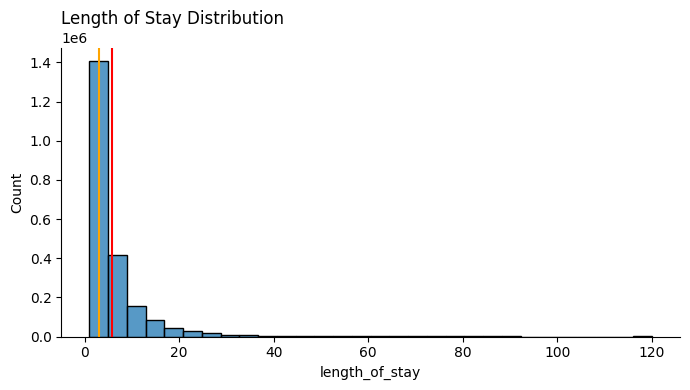

In [35]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x=col,
    bins=30,
    kde=False
)

sns.despine()
plt.axvline(df_temp['mean'].item(), color = "red")
plt.axvline(df_temp['median'].item(), color = "orange")
plt.title("Length of Stay Distribution", loc="left")
# plt.xlabel("Length of Stay Days")
# plt.ylabel("Number of Discharges")
plt.tight_layout()
plt.show()

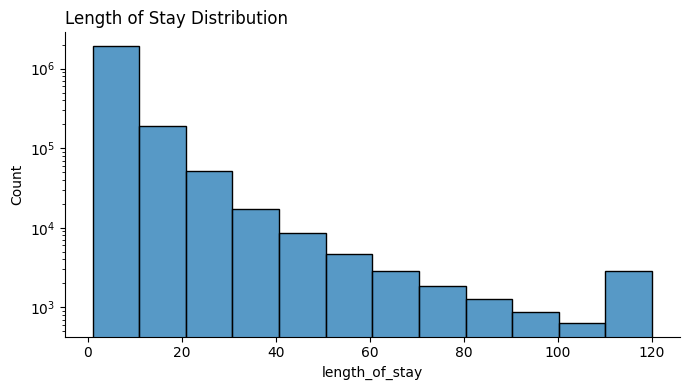

In [36]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x=col,
    bins=12,
    kde=False
)

sns.despine()
plt.title("Length of Stay Distribution", loc="left")
plt.yscale("log")
plt.tight_layout()
plt.show()

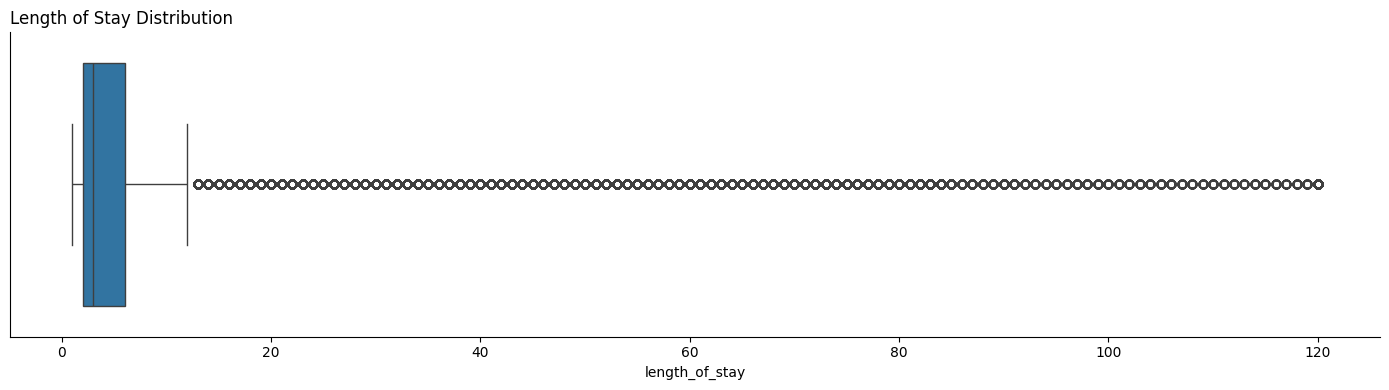

In [37]:
plt.figure(figsize=(14, 4))

sns.boxplot(
    x = df[col]
    )

sns.despine()
plt.title("Length of Stay Distribution", loc="left")
plt.yticks([])
plt.tight_layout()
plt.show()

In [38]:
df["length_of_stay"].quantile(q= [0.15, 0.25, 0.5, 0.75, 0.95, 0.99])

,length_of_stay
0.15,1.0
0.25,2.0
0.50,3.0
0.75,6.0
0.95,19.0
0.99,42.0


### Type of Admission

In [39]:
col = "type_of_admission"
df_temp = get_number_of_instances(df, col)
df_temp

,type_of_admission,number_of_instances,percent
0,Emergency,1460204,66.471498
1,Elective,355896,16.201120
2,Newborn,198219,9.023338
3,Urgent,168716,7.680300
4,Trauma,10050,0.457497
5,Not Available,3652,0.166247


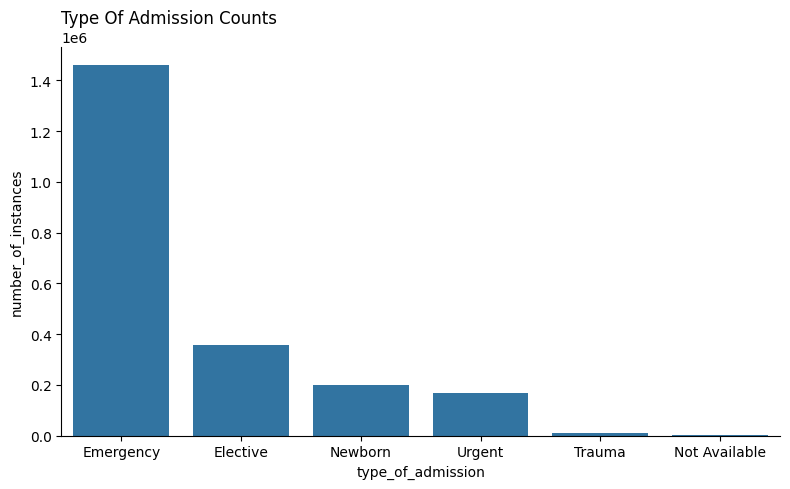

In [40]:
barplot(df_temp, col, figsize=(8, 5))

### Patient Disposition

In [41]:
col = "patient_disposition"
df_temp = get_number_of_instances(df, col)
df_temp

,patient_disposition,number_of_instances,percent
0,Home or Self Care,1441830,65.635076
1,Home w/ Home Health Services,299705,13.643190
2,Skilled Nursing Home,211258,9.616900
3,Left Against Medical Advice,57701,2.626669
4,Expired,54460,2.479132
5,Short-term Hospital,38487,1.752008
6,Inpatient Rehabilitation Facility,35860,1.632421
7,Hospice - Home,11241,0.511714
8,Psychiatric Hospital or Unit of Hosp,9954,0.453127
9,Hospice - Medical Facility,9856,0.448665


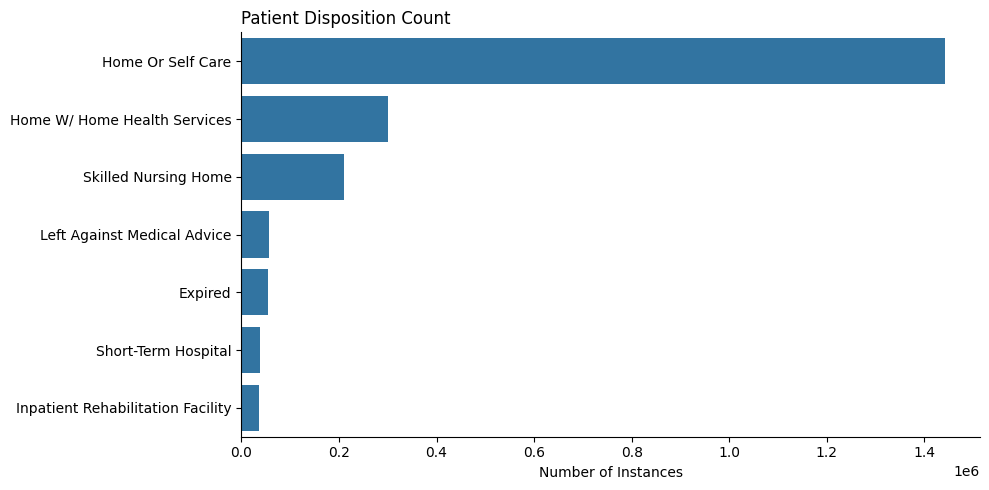

In [42]:
horizontal_barplot(df_temp.head(7), col, figsize=(10,5))

In [43]:
#the persentage of the first 5 values
df_temp.iloc[:5, 2].sum().round().item()

94.0

### CCSR Diagnosis Description

In [44]:
col = "ccsr_diagnosis_description"
df_temp = get_number_of_instances(df, col)
df_temp.head(7)

,ccsr_diagnosis_description,number_of_instances,percent
0,LIVEBORN,199274,9.071364
1,SEPTICEMIA,163590,7.446954
2,HEART FAILURE,62449,2.842807
3,DIABETES MELLITUS WITH COMPLICATION,43811,1.994367
4,ALCOHOL-RELATED DISORDERS,39837,1.813462
5,PNEUMONIA (EXCEPT THAT CAUSED BY TUBERCULOSIS),37151,1.691190
6,CARDIAC DYSRHYTHMIAS,37083,1.688095


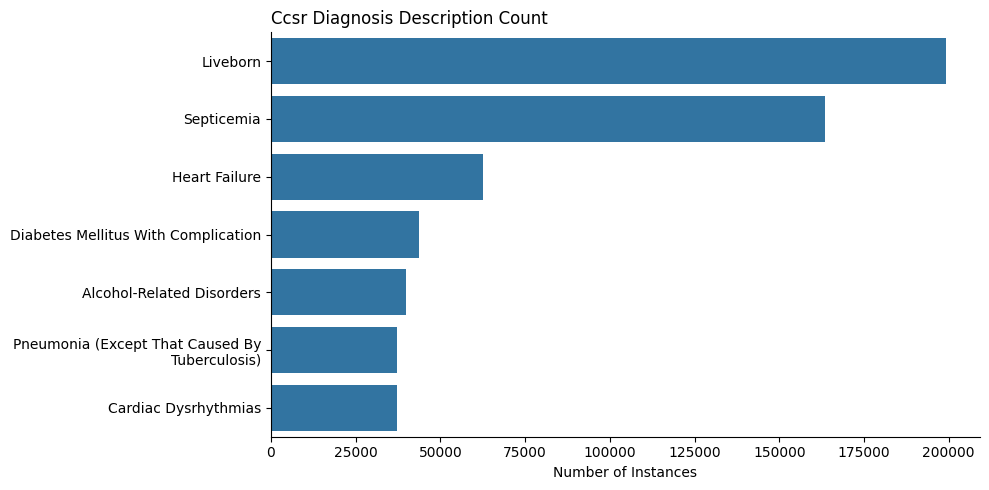

In [45]:
horizontal_barplot(df_temp.head(7), col, figsize = (10, 5))

### APR DRG Description

In [46]:
col = "apr_drg_description"
df_temp = get_number_of_instances(df, col)
df_temp.head(7)

,apr_drg_description,number_of_instances,percent
0,"NEONATE BIRTH WEIGHT > 2499 GRAMS, NORMAL NEWB...",168494,7.670194
1,SEPTICEMIA AND DISSEMINATED INFECTIONS,144367,6.571884
2,VAGINAL DELIVERY,123398,5.617332
3,HEART FAILURE,60015,2.732007
4,CESAREAN SECTION WITHOUT STERILIZATION,59419,2.704875
5,OTHER PNEUMONIA,33096,1.506598
6,KIDNEY AND URINARY TRACT INFECTIONS,32638,1.485749


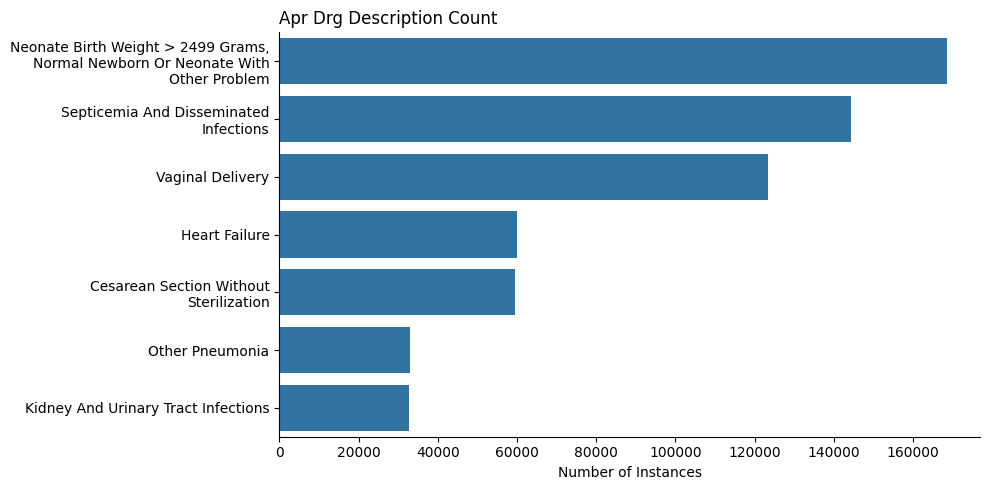

In [47]:
horizontal_barplot(df_temp.head(7), col, figsize=(10, 5))

### APR MDC Description

In [243]:
col = "apr_mdc_description"
df_temp = get_number_of_instances(df, col)
df_temp.head(7)

,apr_mdc_description,number_of_instances,percent
0,DISEASES AND DISORDERS OF THE CIRCULATORY SYSTEM,277625,12.638063
1,"PREGNANCY, CHILDBIRTH AND THE PUERPERIUM",219991,10.014444
2,NEWBORNS AND OTHER NEONATES WITH CONDTN ORIG I...,203604,9.268474
3,"INFECTIOUS AND PARASITIC DISEASES, SYSTEMIC OR...",183022,8.331539
4,DISEASES AND DISORDERS OF THE RESPIRATORY SYSTEM,180502,8.216823
5,DISEASES AND DISORDERS OF THE DIGESTIVE SYSTEM,172157,7.836942
6,DISEASES AND DISORDERS OF THE MUSCULOSKELETAL ...,171033,7.785775


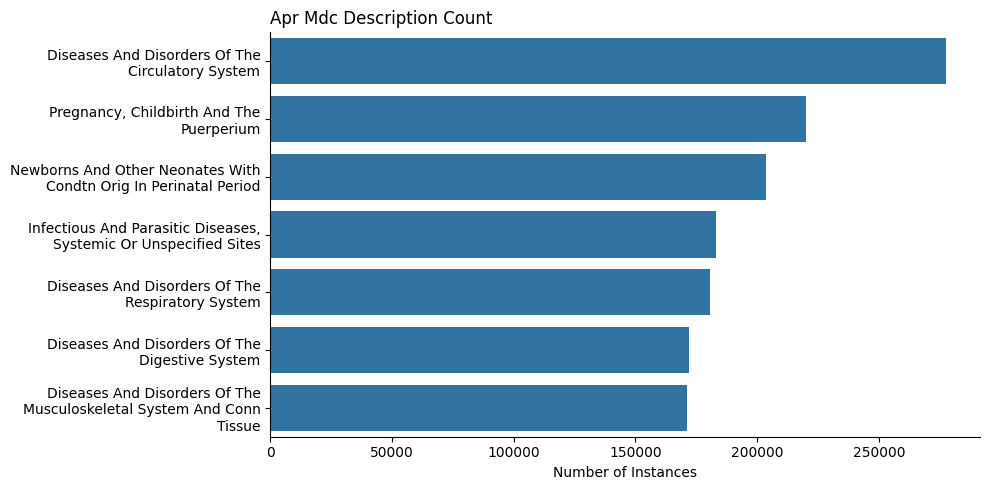

In [244]:
horizontal_barplot(df_temp.head(7), col, figsize = (10, 5))

In [246]:
find_num_groups(df_temp, 80)[0]

10

### APR Severity of Illness Code

In [50]:
col = "apr_severity_of_illness_code"
df_temp = get_summary_stats(df, col)
df_temp

index,column_name,mean,median,mode,q1,q3,std,var
0,apr_severity_of_illness_code,2.145497,2.0,2.0,1.0,3.0,0.925232,0.856053


### APR Severity of Illness

In [51]:
col = "apr_severity_of_illness"
df_temp = get_number_of_instances(df, col)
df_temp

,apr_severity_of_illness,number_of_instances,percent
0,Moderate,820465,37.349259
1,Minor,619207,28.187580
2,Major,573480,26.105993
3,Extreme,183129,8.336410
4,Undetermined,456,0.020758


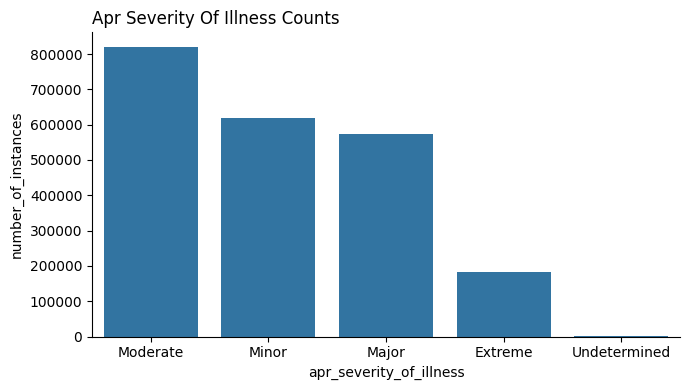

In [52]:
barplot(df_temp, col, figsize=(7, 4))

### APR Risk of Mortality

In [53]:
col = "apr_risk_of_mortality"
df_temp = get_number_of_instances(df, col)
df_temp

,apr_risk_of_mortality,number_of_instances,percent
0,Minor,1108093,50.442679
1,Moderate,477108,21.718940
2,Major,440239,20.040587
3,Extreme,170841,7.777035
4,Undetermined,456,0.020758


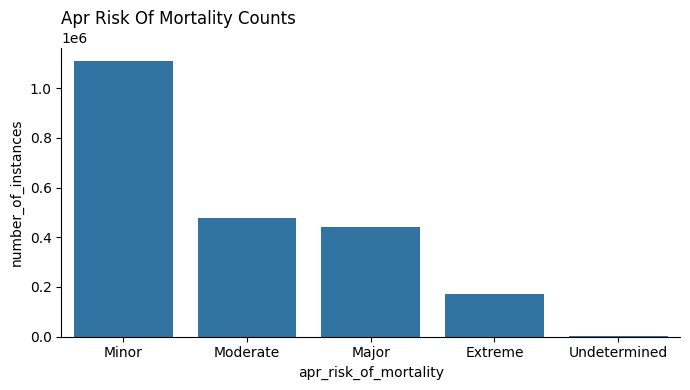

In [54]:
barplot(df_temp, col, figsize=(7, 4))

### APR Medical Surgical

In [55]:
col = "apr_medical_surgical"
df_temp = get_number_of_instances(df, col)
df_temp

,apr_medical_surgical,number_of_instances,percent
0,Medical,1686244,76.761306
1,Surgical,510037,23.217936
2,Not Applicable,456,0.020758


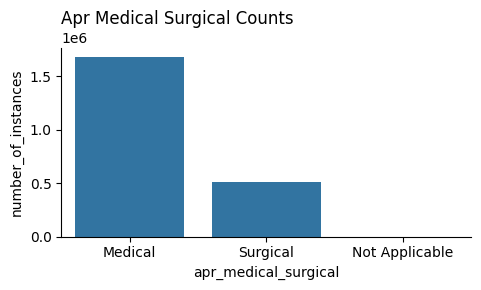

In [56]:
barplot(df_temp, col, figsize = (5, 3))

### Payment Typology

In [57]:
col = "payment_typology_1"
df_temp = get_number_of_instances(df, col)
df_temp

,payment_typology_1,number_of_instances,percent
0,Medicare,929267,42.306523
1,Medicaid,635606,28.937087
2,Private Health Insurance,317827,14.469636
3,Blue Cross/Blue Shield,204165,9.294972
4,Self-Pay,34786,1.583694
5,"Managed Care, Unspecified",30320,1.380372
6,Miscellaneous/Other,21764,0.990845
7,Federal/State/Local/VA,21140,0.962436
8,Department of Corrections,1635,0.074436


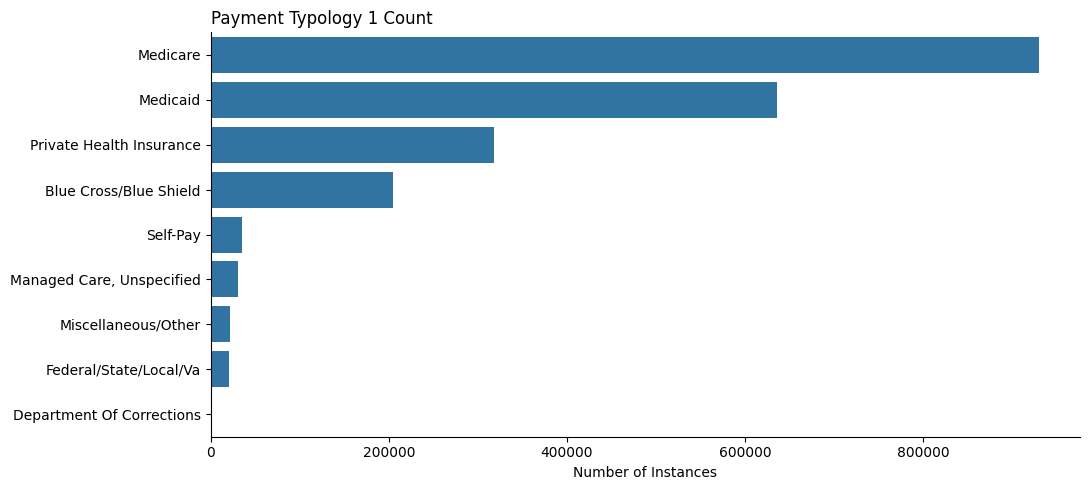

In [58]:
horizontal_barplot(df_temp, col)

### Emergency Department Indicator

In [59]:
col = "emergency_department_indicator"
df_temp = get_number_of_instances(df, col)
df_temp

,emergency_department_indicator,number_of_instances,percent
0,Y,1377141,62.690299
1,N,819596,37.309701


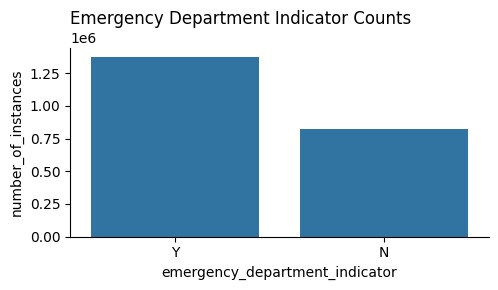

In [60]:
barplot(df_temp, col, figsize = (5, 3))

### Total Charges

In [61]:
col = "total_charges"
df_temp = get_summary_stats(df, col)
df_temp

index,column_name,mean,median,mode,q1,q3,std,var
0,total_charges,90625.430221,47243.79,13890.0,23576.38,94515.16,189402.170295,3.587318e+10


In [62]:
df[col].quantile([0.15, 0.25, 0.5, 0.75, 0.95, 0.99])

,total_charges
0.15,16580.1040
0.25,23576.3800
0.50,47243.7900
0.75,94515.1600
0.95,289019.8960
0.99,715906.0144


In [63]:
mask = df[col] >= 2e5

df[mask].shape[0]

198667

In [64]:
df[col].agg(['min', 'max'])

,total_charges
min,0.00
max,19694856.95


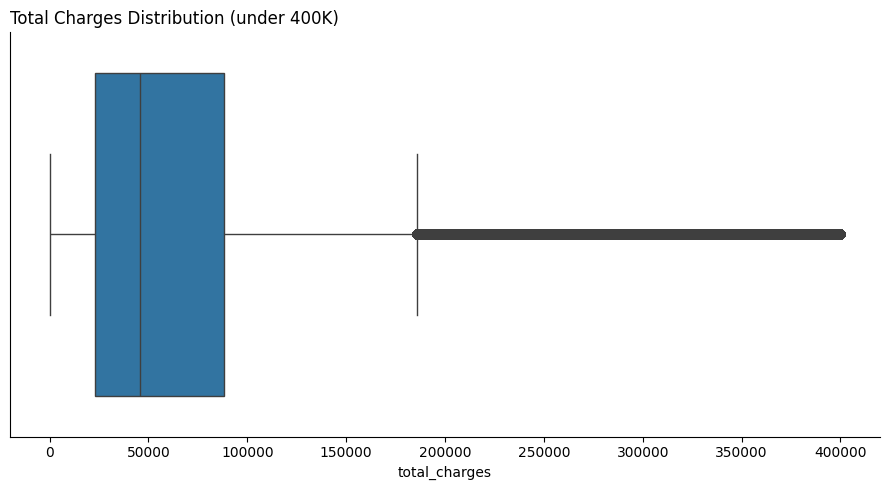

In [65]:
mask = df[col] <= 4e5

plt.figure(figsize=(9,5))

sns.boxplot(
    x = df.loc[mask, col]
    )

sns.despine()
plt.title(f"Total Charges Distribution (under 400K)", loc = "left")
plt.yticks([])
plt.tight_layout()
plt.show()

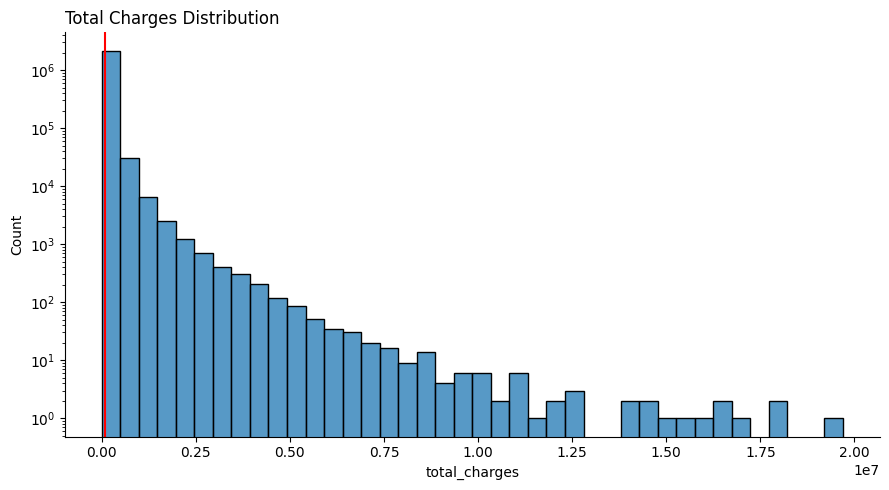

In [66]:
plt.figure(figsize  = (9, 5))

sns.histplot(
    data = df,
    x = col,
    bins = 40,
    kde = False

)

sns.despine()
plt.axvline(df_temp["mean"].item(), color = "red")
plt.title(f"Total Charges Distribution", loc = "left")
plt.yscale("log")
plt.tight_layout()
plt.show()

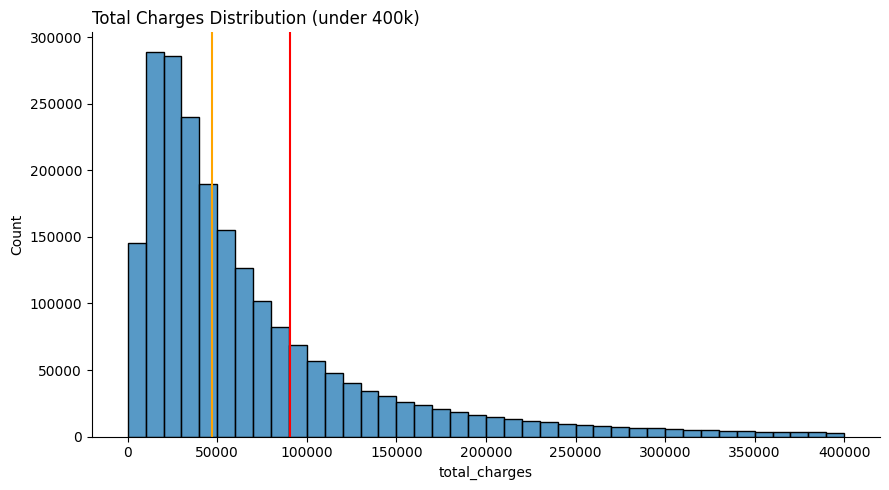

In [67]:
mask = df[col] < 4e5

plt.figure(figsize  = (9, 5))

sns.histplot(
    data = df[mask],
    x = col,
    bins = 40,
    kde = False

)

sns.despine()
plt.title(f"Total Charges Distribution (under 400k)", loc = "left")
plt.axvline(df_temp["mean"].item(), color = "red")
plt.axvline(df_temp["median"].item(), color = "orange")
plt.tight_layout()
plt.show()

### Total Costs

In [68]:
col = "total_costs"
df_temp = get_summary_stats(df, col)
df_temp

index,column_name,mean,median,mode,q1,q3,std,var
0,total_costs,26416.584062,14110.45,3191.05,7415.88,27788.34,55372.286312,3.066090e+09


In [69]:
df[col].quantile([0.25, 0.5, 0.75, 0.95, 0.99])

,total_costs
0.25,7415.8800
0.50,14110.4500
0.75,27788.3400
0.95,82095.8160
0.99,202242.0572


In [70]:
mask = df[col] >= 1e5

df[mask].shape[0]

77933

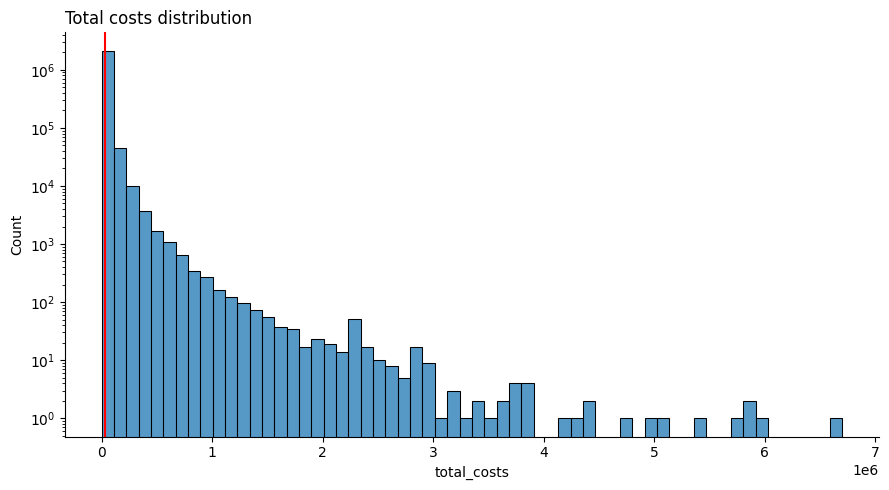

In [71]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data = df,
    x = col,
    bins = 60,
    kde = False
)

sns.despine()
plt.title("Total costs distribution", loc = "left")
plt.axvline(df_temp["mean"].item(), color = "red")
plt.yscale("log")
plt.tight_layout()
plt.show()

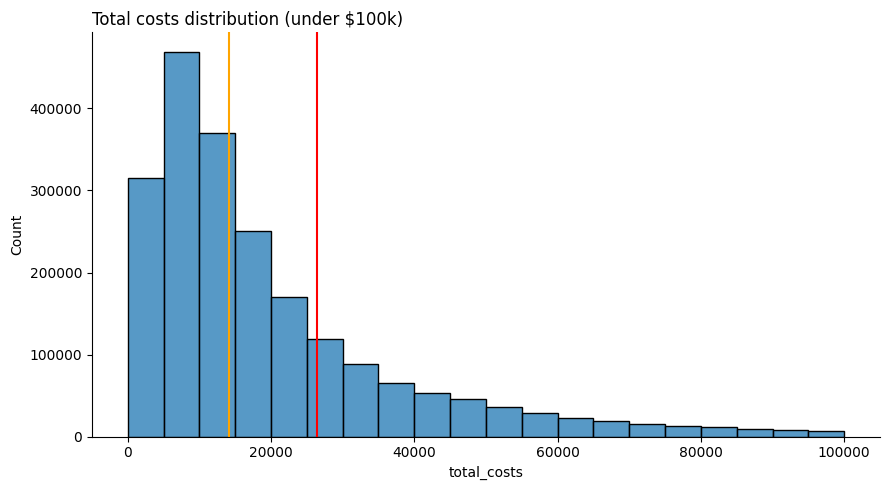

In [72]:
mask = df[col] <= 1e5

plt.figure(figsize=(9, 5))

sns.histplot(
    data = df[mask],
    x = col,
    bins = 20,
    kde = False
)


sns.despine()
plt.axvline(df_temp["mean"].item(), color = "red")
plt.axvline(df_temp["median"].item(), color = "orange")
plt.title("Total costs distribution (under $100k)", loc = "left")
plt.tight_layout()
plt.show()

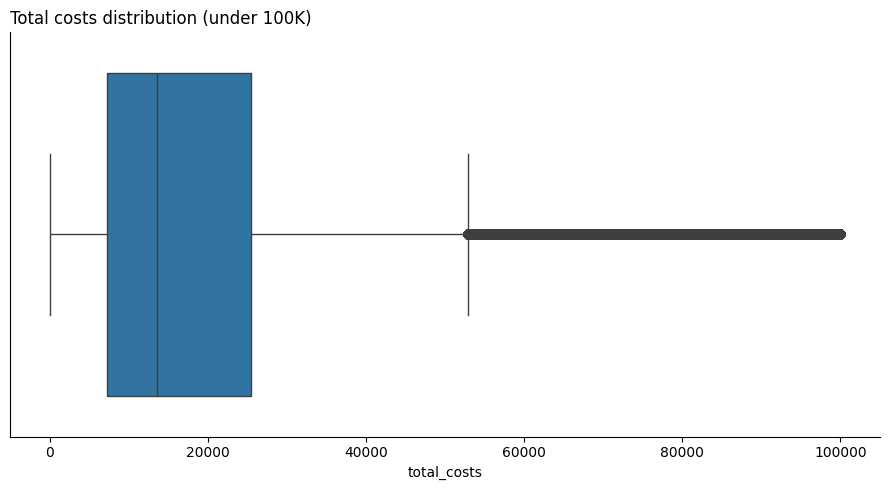

In [73]:
mask = df[col] <= 1e5

plt.figure(figsize=(9,5))

sns.boxplot(
    x = df.loc[mask, col]
    )

sns.despine()
plt.title("Total costs distribution (under 100K)", loc = "left")
plt.yticks([])
plt.tight_layout()
plt.show()

### CCSR Procedure Description

In [74]:
col = "ccsr_procedure_description"
df_temp = get_number_of_instances(df, col)
df_temp.head(7)

,ccsr_procedure_description,number_of_instances,percent
0,SPONTANEOUS VAGINAL DELIVERY,115706,7.450612
1,CESAREAN SECTION,65817,4.238129
2,VACCINATIONS,64265,4.138192
3,NON-INVASIVE VENTILATION,54012,3.477974
4,"ADMINISTRATION OF THERAPEUTIC SUBSTANCES, NEC",51708,3.329614
5,ADMINISTRATION OF ANTIBIOTICS,43394,2.794253
6,TRANSFUSION OF BLOOD AND BLOOD PRODUCTS,38452,2.476025


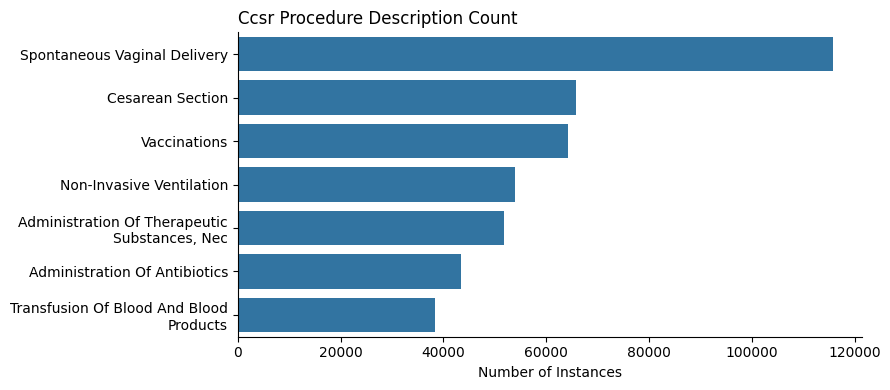

In [75]:
horizontal_barplot(df_temp.head(7), col, figsize=(9, 4))

In [76]:
num_nulls = get_num_nulls(df, col)
num_nulls, round(num_nulls/df[col].shape[0] * 100, 2 )

643764 29.31


# Relationships (Multivariate)

### Correlation: length of stay, severity of illness, total charges, total costs



In [77]:
new_col_names = ["stay", "illness severity", "charges", "costs"]

df_temp = df.drop(columns=["discharge_year", "length_of_stay_120_plus_flag"]).corr(numeric_only = True)
mapping = dict(zip(df_temp.columns, new_col_names))
df_temp = df_temp.rename(columns=mapping, index=mapping)
df_temp

,stay,illness severity,charges,costs
stay,1.000000,0.336349,0.661864,0.688224
illness severity,0.336349,1.000000,0.297997,0.289023
charges,0.661864,0.297997,1.000000,0.873947
costs,0.688224,0.289023,0.873947,1.000000


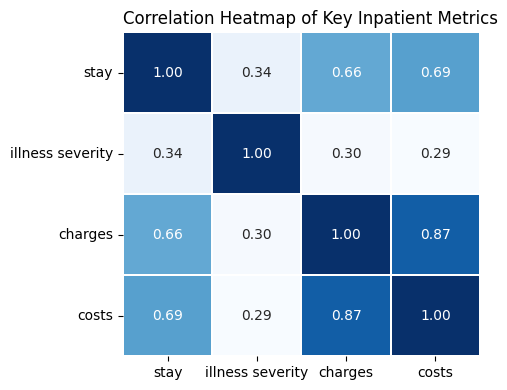

In [78]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    data = df_temp,
    fmt = ".2f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.title("Correlation Heatmap of Key Inpatient Metrics", loc = "left")
plt.yticks(rotation = 0)
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

### Contingency: APR Severity of Illness, APR Risk Of Mortality

In [305]:
col1 = "apr_severity_of_illness"
col2 = "apr_risk_of_mortality"
ordered_cols = ["Extreme", "Major", "Moderate", "Minor", "Undetermined"]

ct =  pd.crosstab(
    df[col1],
    df[col2]
)

ct = ct.reindex(index = ordered_cols, columns = ordered_cols)
df_temp = ct.div(ct.sum(axis = 1), axis = 0) * 100 #row normalizes

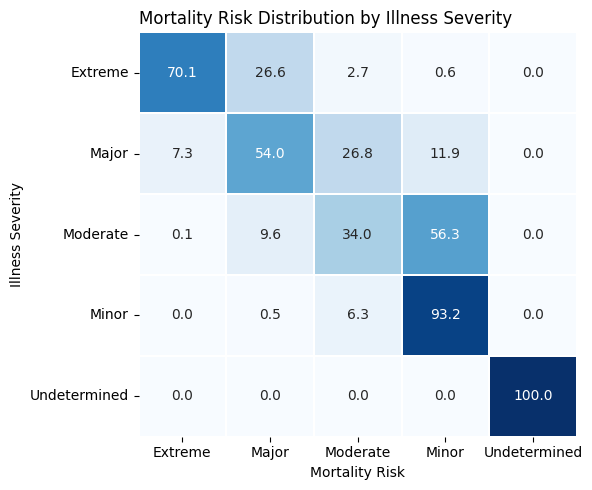

In [306]:
plt.figure(figsize = (6,5))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.ylabel("Illness Severity")
plt.xlabel("Mortality Risk")
plt.title("Mortality Risk Distribution by Illness Severity", loc = "left")
plt.tight_layout()
plt.show()

In [307]:
#column normalized
df_temp = ct.div(ct.sum(axis = 0), axis=1) * 100

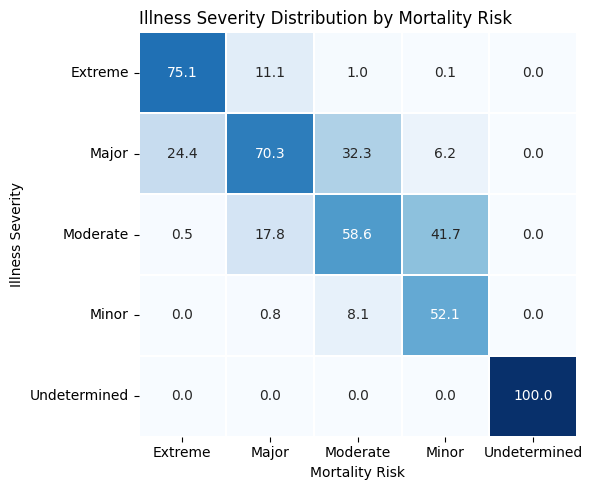

In [308]:
plt.figure(figsize = (6,5))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.xlabel("Mortality Risk")
plt.ylabel("Illness Severity")
plt.title("Illness Severity Distribution by Mortality Risk", loc = "left")
plt.tight_layout()
plt.show()

In [309]:
#joint distribution
df_temp = ct / ct.to_numpy().sum() * 100

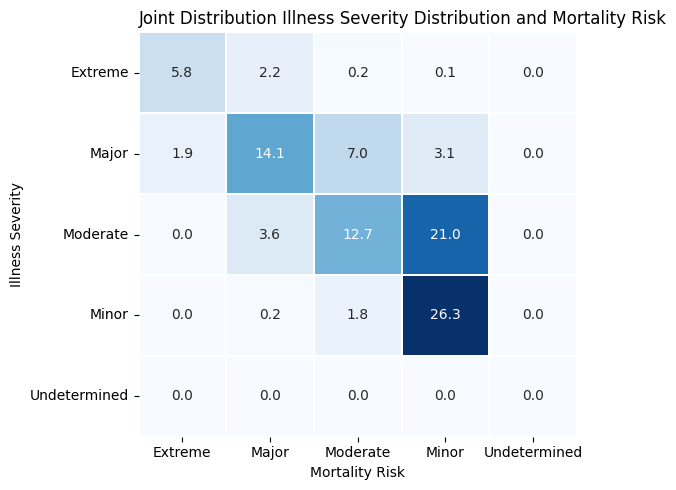

In [310]:
plt.figure(figsize = (6,5))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.xlabel("Mortality Risk")
plt.ylabel("Illness Severity")
plt.title("Joint Distribution Illness Severity Distribution and Mortality Risk", loc = "left")
plt.tight_layout()
plt.show()

### Contingency: APR Severity of Illness, Patient Disposiiton

In [298]:
col1 = "patient_disposition"
col2 = "apr_severity_of_illness"
pd_order = [
    "Expired",
    "Left Against Medical Advice",
    "Skilled Nursing Home",
    "Home w/ Home Health Services",
    "Home or Self Care",
    ]
si_order = [
    "Extreme",
    "Major",
    "Moderate",
    "Minor",
    "Undetermined"
    ]
mask = df[col1].isin(pd_order)


ct =  pd.crosstab(
    df.loc[mask, col1],
    df.loc[:, col2],
) * 100

ct = ct.reindex(columns = si_order, index = pd_order)

In [299]:
#index normalized
df_temp = ct.div(ct.sum(axis = 1), axis = 0) * 100

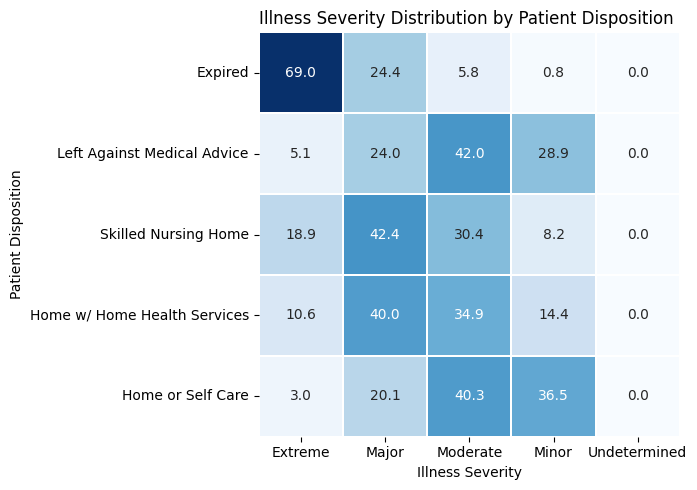

In [300]:
plt.figure(figsize = (7,5))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.xlabel("Illness Severity")
plt.ylabel("Patient Disposition")
plt.title("Illness Severity Distribution by Patient Disposition", loc = "left")
plt.tight_layout()
plt.show()

In [301]:
#column normalized
df_temp = ct.div(ct.sum(axis = 0), axis = 1) * 100

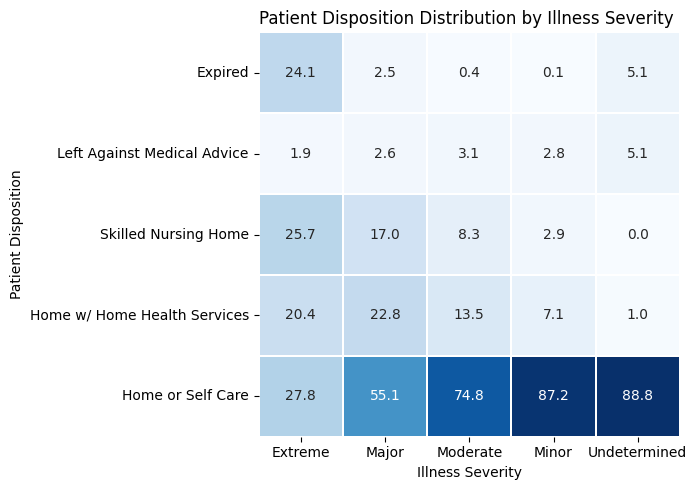

In [302]:
plt.figure(figsize = (7,5))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.xlabel("Illness Severity")
plt.ylabel("Patient Disposition")
plt.title("Patient Disposition Distribution by Illness Severity", loc = "left")
plt.tight_layout()
plt.show()

In [303]:
#joint distribution
df_temp = ct / ct.to_numpy().sum() * 100

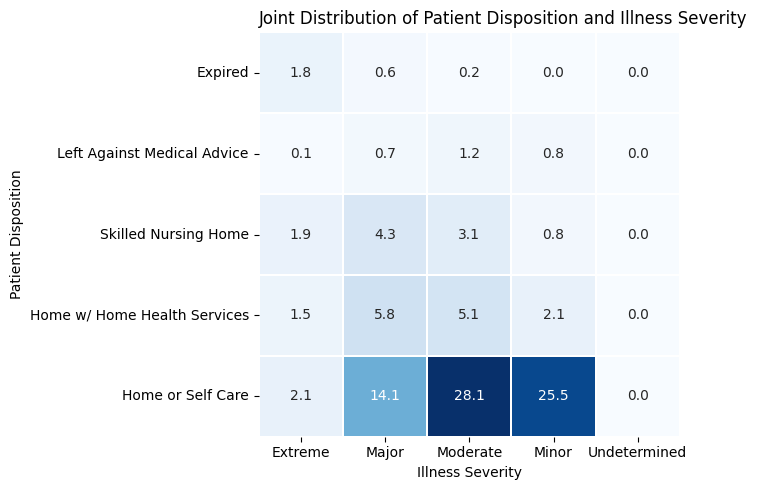

In [304]:
plt.figure(figsize = (7,5))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.xlabel("Illness Severity")
plt.ylabel("Patient Disposition")
plt.title("Joint Distribution of Patient Disposition and Illness Severity", loc = "left")
plt.tight_layout()
plt.show()

# Test Area

In [ ]:
#